# Jaguar Re-ID — Linear Model (Upgraded)

**Architecture**: Flatten → Dense(31, softmax)  
**Improvements over baseline**: data augmentation, L2 regularization, LR scheduling.

| | Baseline | Upgraded |
|---|---|---|
| Augmentation | ✗ | Flip + Brightness + Contrast |
| Regularization | ✗ | L2 (swept) |
| LR scheduling | ✗ | ReduceLROnPlateau |
| HP study | optimizer, lr, act | **L2 strength + LR** |

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks, regularizers
from sklearn.preprocessing import normalize

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.20.0
GPU: []


In [2]:
PROJECT_ROOT  = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR      = os.path.join(PROJECT_ROOT, 'data')
CLEANED_DIR   = os.path.join(DATA_DIR, 'cleaned')
TRAIN_IMG_DIR = os.path.join(CLEANED_DIR, 'train')
TEST_IMG_DIR  = os.path.join(CLEANED_DIR, 'test')
OUTPUT_DIR    = os.path.join(PROJECT_ROOT, 'outputs')
SUBMISSION_DIR = os.path.join(PROJECT_ROOT, 'submissions')
LOG_DIR = r'C:\tf\logs'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

IMG_SIZE    = 224
NUM_CLASSES = 31
BATCH_SIZE  = 32
SEED        = 42
AUTOTUNE    = tf.data.AUTOTUNE

tf.random.set_seed(SEED)
np.random.seed(SEED)

## 1. Data loading

In [3]:
train_df      = pd.read_csv(os.path.join(CLEANED_DIR, 'train_split.csv'))
val_df        = pd.read_csv(os.path.join(CLEANED_DIR, 'val_split.csv'))
test_pairs_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test pairs: {len(test_pairs_df)}")

def load_test_images(img_dir):
    test_images = {}
    for fname in sorted(os.listdir(img_dir)):
        if fname.endswith('.png'):
            img = Image.open(os.path.join(img_dir, fname)).convert('RGB')
            test_images[fname] = np.array(img, dtype=np.float32) / 255.0
    return test_images

print("Loading test images...")
test_images = load_test_images(TEST_IMG_DIR)
print(f"Test images: {len(test_images)}")

Train: 1516 | Val: 379 | Test pairs: 137270
Loading test images...
Test images: 371


## 2. Data augmentation pipeline

Even for a linear model, augmentation artificially increases the dataset size and reduces overfitting.  
We keep only augmentations that preserve jaguar spot patterns: **no vertical flip, no heavy distortion**.

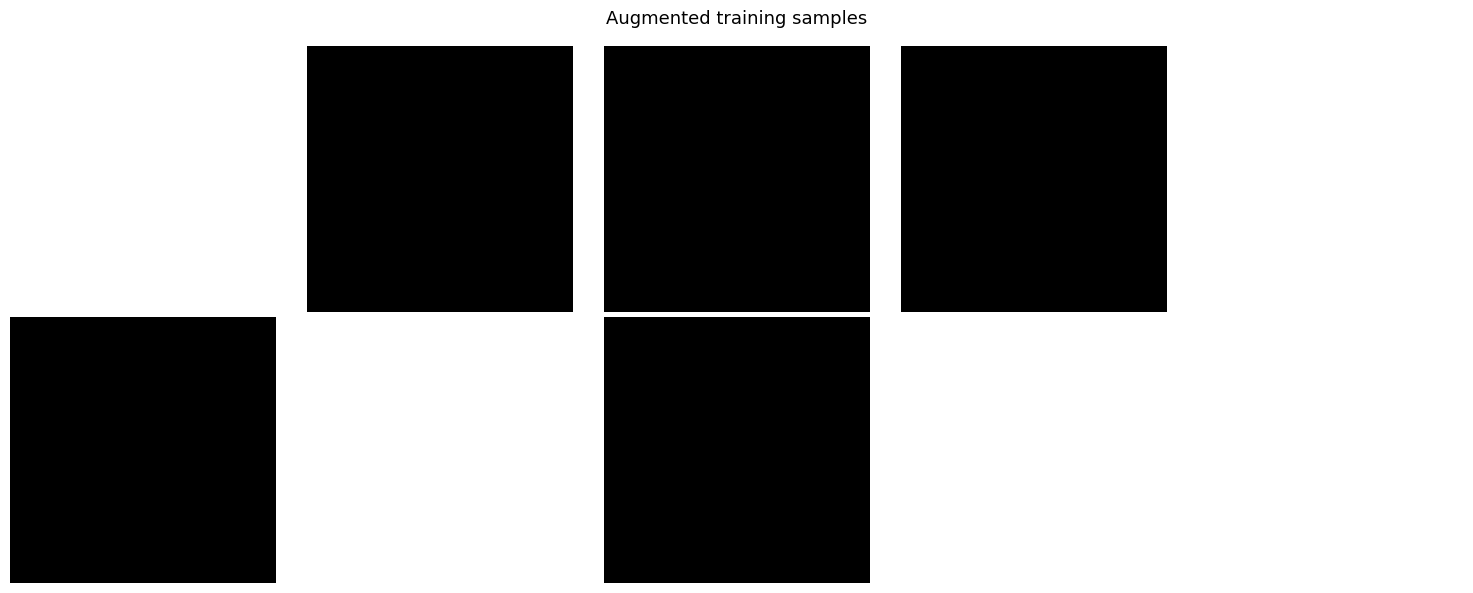

In [4]:
augmentation_layers = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
], name='augmentation')

def make_dataset(df, img_dir, training=False):
    paths  = [os.path.join(img_dir, fn) for fn in df['filename']]
    labels = df['label'].values.tolist()

    def load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=2000, seed=SEED)
        ds = ds.batch(BATCH_SIZE)
        ds = ds.map(
            lambda x, y: (augmentation_layers(x, training=True), y),
            num_parallel_calls=AUTOTUNE
        )
    else:
        ds = ds.batch(BATCH_SIZE)
    return ds.prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, TRAIN_IMG_DIR, training=True)
val_ds   = make_dataset(val_df,   TRAIN_IMG_DIR, training=False)

# Visualize augmented samples
sample_batch, _ = next(iter(train_ds))
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Augmented training samples', fontsize=13)
for i in range(10):
    axes[i // 5][i % 5].imshow(np.clip(sample_batch[i].numpy(), 0, 1))
    axes[i // 5][i % 5].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'linear_upgraded_augmented_samples.png'), dpi=120, bbox_inches='tight')
plt.show()

## 3. Model architecture

Same structure as baseline but with **L2 regularization** on the Dense layer.  
With 4.6M parameters and only 1516 training samples, regularization is essential.

In [5]:
def build_linear_model(l2_strength=1e-3):
    return keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Flatten(),
        layers.Dense(
            NUM_CLASSES,
            activation='softmax',
            kernel_regularizer=regularizers.l2(l2_strength)
        )
    ], name=f'linear_l2_{l2_strength}')

build_linear_model().summary()

Model: "linear_l2_0.001"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 31)             │     4,666,399 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,666,399 (17.80 MB)

 Trainable params: 4,666,399 (17.80 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Hyperparameter study

We sweep two key parameters independently:
- **L2 regularization strength**: controls how much we penalize large weights
- **Learning rate**: controls the speed of convergence

Both runs use `ReduceLROnPlateau` and early stopping.

In [6]:
def train_and_eval(model, lr=1e-3, run_name='run'):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, 'linear_upgraded_hp', run_name)
    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir)
        ],
        verbose=0
    )
    _, val_acc = model.evaluate(val_ds, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (stopped at epoch {best_epoch})")
    return val_acc, hist

In [7]:
# --- L2 sweep (fixed lr=1e-3) ---
l2_candidates = [0.0, 1e-4, 1e-3, 1e-2]
l2_results = {}

print("=== L2 regularization sweep (lr=1e-3) ===")
for l2 in l2_candidates:
    m = build_linear_model(l2_strength=l2)
    val_acc, hist = train_and_eval(m, lr=1e-3, run_name=f'l2_{l2}')
    l2_results[l2] = {'val_acc': val_acc, 'hist': hist.history}

=== L2 regularization sweep (lr=1e-3) ===
  l2_0.0: val_acc=0.2955 (stopped at epoch 96)
  l2_0.0001: val_acc=0.2902 (stopped at epoch 85)
  l2_0.001: val_acc=0.3113 (stopped at epoch 99)
  l2_0.01: val_acc=0.2005 (stopped at epoch 52)


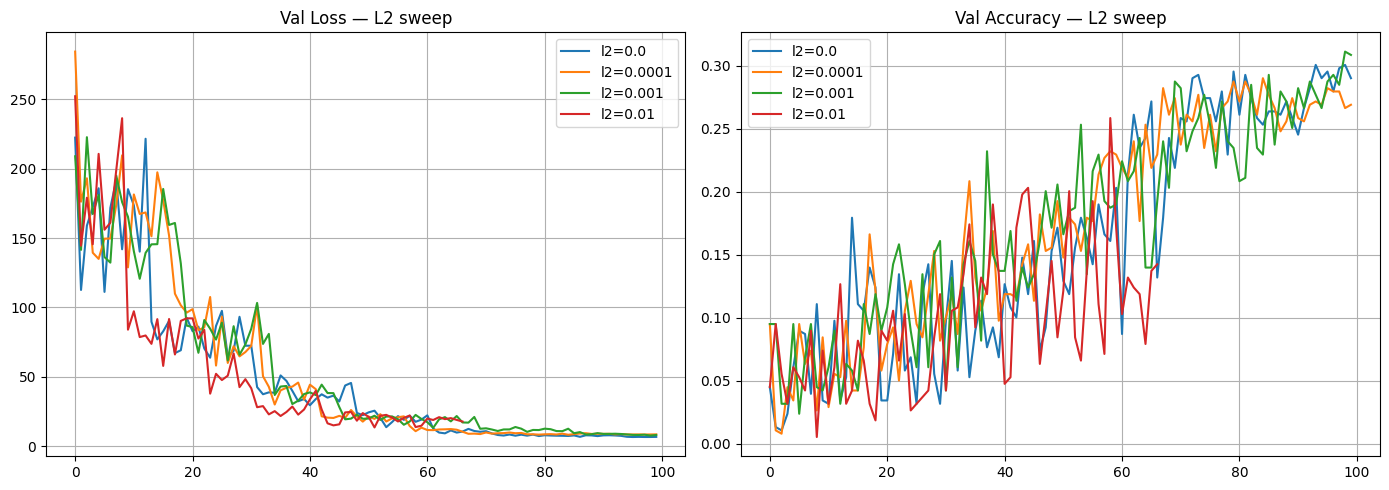

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for l2, res in l2_results.items():
    axes[0].plot(res['hist']['val_loss'],     label=f'l2={l2}')
    axes[1].plot(res['hist']['val_accuracy'], label=f'l2={l2}')
axes[0].set_title('Val Loss — L2 sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy — L2 sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'linear_upgraded_l2_sweep.png'), dpi=120, bbox_inches='tight')
plt.show()

In [9]:
# --- LR sweep (fixed l2=1e-3) ---
lr_candidates = [1e-2, 1e-3, 1e-4]
lr_results = {}

print("=== Learning rate sweep (l2=1e-3) ===")
for lr in lr_candidates:
    m = build_linear_model(l2_strength=1e-3)
    val_acc, hist = train_and_eval(m, lr=lr, run_name=f'lr_{lr}')
    lr_results[lr] = {'val_acc': val_acc, 'hist': hist.history}

=== Learning rate sweep (l2=1e-3) ===
  lr_0.01: val_acc=0.2876 (stopped at epoch 96)
  lr_0.001: val_acc=0.2850 (stopped at epoch 96)
  lr_0.0001: val_acc=0.2111 (stopped at epoch 72)


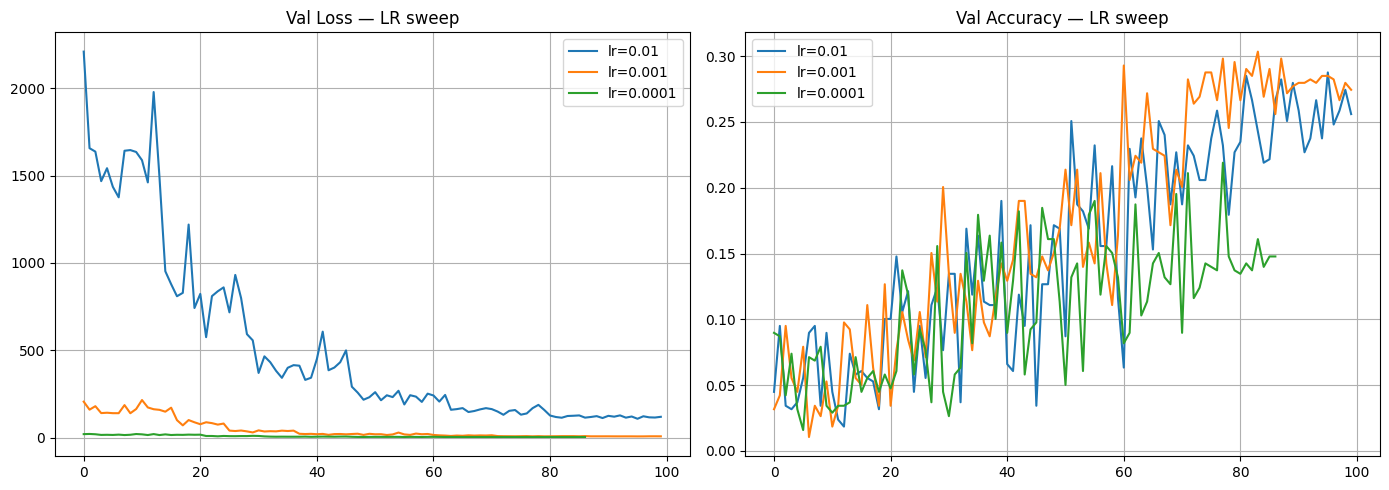

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lr, res in lr_results.items():
    axes[0].plot(res['hist']['val_loss'],     label=f'lr={lr}')
    axes[1].plot(res['hist']['val_accuracy'], label=f'lr={lr}')
axes[0].set_title('Val Loss — LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy — LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'linear_upgraded_lr_sweep.png'), dpi=120, bbox_inches='tight')
plt.show()

## 5. Results summary

In [11]:
rows = []
for l2, res in l2_results.items():
    rows.append({'Config': f'l2={l2}, lr=1e-3', 'Val Accuracy': res['val_acc']})
for lr, res in lr_results.items():
    rows.append({'Config': f'l2=1e-3, lr={lr}', 'Val Accuracy': res['val_acc']})

results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
print("=== HP Study Results ===")
display(results_df)

best_row = results_df.iloc[0]
print(f"\nBest config: {best_row['Config']} → val_acc={best_row['Val Accuracy']:.4f}")

=== HP Study Results ===


,Config,Val Accuracy
0,"l2=0.001, lr=1e-3",0.311346
1,"l2=0.0, lr=1e-3",0.295515
2,"l2=0.0001, lr=1e-3",0.290237
3,"l2=1e-3, lr=0.01",0.287599
4,"l2=1e-3, lr=0.001",0.284960
5,"l2=1e-3, lr=0.0001",0.211082
6,"l2=0.01, lr=1e-3",0.200528



Best config: l2=0.001, lr=1e-3 → val_acc=0.3113


## 6. Final training on full dataset

Retrain on all available data (train + val) with the best hyperparameters.  
Update `BEST_L2` and `BEST_LR` from the results above before running.

In [12]:
BEST_L2 = 1e-3  # update from results_df
BEST_LR = 1e-3  # update from results_df

all_train_df = pd.read_csv(os.path.join(CLEANED_DIR, 'train_clean.csv'))
print("Building full-train dataset (lazy)...")
full_ds = make_dataset(all_train_df, TRAIN_IMG_DIR, training=True)

final_model = build_linear_model(l2_strength=BEST_L2)
final_model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_log_dir = os.path.join(LOG_DIR, 'linear_upgraded_final', datetime.now().strftime('%Y%m%d-%H%M%S'))
final_hist = final_model.fit(
    full_ds,
    epochs=80,
    callbacks=[
        callbacks.ReduceLROnPlateau(
            monitor='loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1
        ),
        callbacks.TensorBoard(log_dir=final_log_dir)
    ],
    verbose=1
)
print(f"Final train acc: {final_hist.history['accuracy'][-1]:.4f}")

Building full-train dataset (lazy)...
Epoch 1/80
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.0591 - loss: 5104.3867 - learning_rate: 0.0010
Epoch 2/80
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.0776 - loss: 2698.7358 - learning_rate: 0.0010
Epoch 3/80
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.0739 - loss: 2728.0676 - learning_rate: 0.0010
Epoch 4/80
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.0660 - loss: 2621.9033 - learning_rate: 0.0010
Epoch 5/80
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.0755 - loss: 2642.5291 - learning_rate: 0.0010
Epoch 6/80
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.0728 - loss: 2861.9778 - learning_rate: 0.0010
Epoch 7/80
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.0691 - loss: 3151.0535 - learning_rate: 0.0010
Epoch 8/80
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.0718 - loss: 2808.3494 - learning_rate: 0.0010
Epoch 9/80
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.0

## 7. Kaggle submission

In [14]:
# Keras 3 (TF 2.20) ne supporte pas final_model.input sur un Sequential
# → reconstruire le modèle d'embedding via la Functional API
inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = inp
for layer in final_model.layers[:-1]:   # toutes les couches sauf le Dense final
    x = layer(x)
embedding_model = keras.Model(inputs=inp, outputs=x, name='linear_embedding')

test_filenames       = sorted(test_images.keys())
test_array           = np.array([test_images[f] for f in test_filenames])  # 371 imgs — OK
test_embeddings      = embedding_model.predict(test_array, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)

print(f"Embeddings shape: {test_embeddings_norm.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx    = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx  = test_pairs_df['gallery_image'].map(fname_to_idx).values

# Chunks pour éviter l'allocation (137270, 150528) → 77 GiB
CHUNK = 1000
similarities = np.empty(len(query_idx), dtype=np.float32)
for start in range(0, len(query_idx), CHUNK):
    sl = slice(start, start + CHUNK)
    q  = test_embeddings_norm[query_idx[sl]]
    g  = test_embeddings_norm[gallery_idx[sl]]
    similarities[sl] = np.clip((q * g).sum(axis=1), 0, 1)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, 'submission_linear_upgraded.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")

sample_sub = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))
assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub)
print("Format OK")
display(submission.head())

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Embeddings shape: (371, 150528)
Saved: c:\Users\Frédéric\Developer\kaggle_jaguar_classification\submissions\submission_linear_upgraded.csv
Format OK


,row_id,similarity
0,0,0.890965
1,1,0.843432
2,2,0.863581
3,3,0.888410
4,4,0.899426


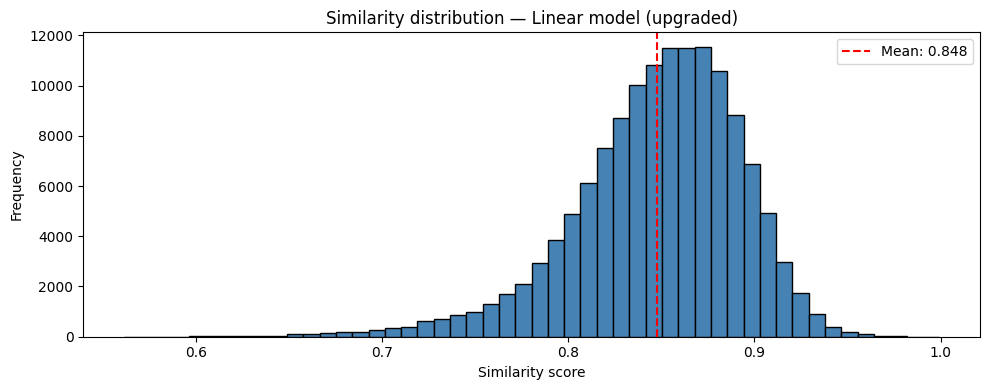

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score')
ax.set_ylabel('Frequency')
ax.set_title('Similarity distribution — Linear model (upgraded)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'linear_upgraded_similarity_distribution.png'), dpi=120, bbox_inches='tight')
plt.show()

## 8. Summary

In [16]:
print("=" * 55)
print("LINEAR MODEL (UPGRADED) — SUMMARY")
print("=" * 55)
print(f"""
Architecture  : Flatten -> Dense(31, softmax)
Regularization: L2 = {BEST_L2}  (swept: {l2_candidates})
Optimizer     : Adam (lr={BEST_LR}, ReduceLROnPlateau)
Augmentation  : RandomFlip + RandomBrightness + RandomContrast
Training      : full dataset ({len(all_train_df)} images), 80 epochs

HP Study top-3:
{results_df.head(3).to_string(index=False)}

Submission    : submissions/submission_linear_upgraded.csv
TensorBoard   : tensorboard --logdir={LOG_DIR}
""")

LINEAR MODEL (UPGRADED) — SUMMARY

Architecture  : Flatten -> Dense(31, softmax)
Regularization: L2 = 0.001  (swept: [0.0, 0.0001, 0.001, 0.01])
Optimizer     : Adam (lr=0.001, ReduceLROnPlateau)
Augmentation  : RandomFlip + RandomBrightness + RandomContrast
Training      : full dataset (1895 images), 80 epochs

HP Study top-3:
            Config  Val Accuracy
 l2=0.001, lr=1e-3      0.311346
   l2=0.0, lr=1e-3      0.295515
l2=0.0001, lr=1e-3      0.290237

Submission    : submissions/submission_linear_upgraded.csv
TensorBoard   : tensorboard --logdir=C:\tf\logs

